# ODE Examples from the Internet

## Lodla-Volterra
From https://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html

- Predator-Prey equation
- system of coupled non-linear differential equations of the first order
- describe interplay between predator and prey populations in an idealized environment
- predator consumes prey, prey reproduces, predator reproduces but depending on the population of prey


$$\frac{dN_1}{dt} = N_1 (\epsilon_1 - \gamma_1 N_2)$$

$$\frac{dN_2}{dt} = -N_2 (\epsilon_2 - \gamma_2 N_1)$$


### Reasoning behind the Equation
(see https://de.wikipedia.org/wiki/Lotka-Volterra-Gleichungen)

- population of prey and predator are designated as $N_1$ and $N_2$, respectivly
- undisturbed growth per time interval $dt$ are designated as $\lambda_1$ and $\lambda_2$ without sign!
- the frequency of predator-prey encounters per $dt$ is $\alpha N_1 N_2$ with $\alpha \geq 0$ and is considered a constant within a biotop
- a great enough number of encounters $n$ have a mean effect $\beta_i$ on the population $N_i$
    - Note: that the effect of a predator-prey encounter has an immediate effect on the prey population is trivial
    - however, the model also assumes that for the predator population; the effect is positive, no doubt, but should be displaced in time, because for the predator it allows reproduction

- based on these general considerations, the SDE is

$$dN_1 = \lambda_1 N_1 dt + \alpha N_1 N_2 \frac{\beta_1}{n}dt \quad | :dt$$

$$dN_2 = \lambda_2 N_2 dt + \alpha N_1 N_2 \frac{\beta_2}{n}dt \quad | :dt$$

- we now divice by $dt$

$$\frac{dN_1}{dt} = \lambda_1 N_1 + \alpha N_1 N_2 \frac{\beta_1}{n}$$

$$\frac{dN_2}{dt} = \lambda_2 N_2 + \alpha N_1 N_2 \frac{\beta_2}{n}$$

- finnaly, we assume, that $\epsilon_1 = \lambda_1$, $\epsilon_2 = - \lambda_2$, $\gamma_1 = -\frac{\alpha \beta_1}{n}$, $\gamma_2 = \frac{\alpha \beta_1}{n}$, and $dt \rightarrow 0$
    - because the predator depends on the prey population for reproduction, we need to change the sign of $\lambda_2$, so that it declines over time; only predator-prey encounters (second term of the predator equation) can raise the predator population
    - the same logic applies to $\gamma_1$, we have to change its sign, because predator-prey encounters remove prey from the population, therefore $\gamma_1 = - \alpha_1 \beta_1 / n$
    
    
*****

- following code assumes

$$\frac{dN_1}{dt} = aN_1 - b N_1 N_2$$

$$\frac{dN_2}{dt} = -c N_2 + d b N_1 N_2$$

- with
    - $a$ as natural growing rate of prey, when there's no predator
    - $b$ as natural dying rate of prey due to predation
    - $c$ as natural dying rate of predators, when there's no prey
    - $d$ as factor describing how many offspring can predators generate per prey

In [1]:
import numpy as np
import pylab as p
from numba import jit, njit

# Defining parameters
a = 1.0
b = 0.1
c = 1.5
#d = 0.75
d = 1

# Function describing the differential equations
#@njit
def dX_dt(X, t = 0):
    """Return the growth rate for the coupled predator-prey popluations at t."""
    N1 = a*X[0] - b*X[0]*X[1]
    N2 = -c*X[1] + d*b*X[0]*X[1]
    return(np.array([N1, N2]))


# Calculating the equilibrium point
X_f0 = np.array([0., 0.]) # Extinction of both species
X_f1 = np.array([c/(d*b), a/b]) # Eq. point of the two species, non-zero!
all(dX_dt(X_f0) == np.zeros(2)) and all(dX_dt(X_f1) == np.zeros(2)) # all() returns true when all iteralble elements return true

# all() example
#all(np.array([1, 2, 3, 4]) == np.array([1, 2, 3, 4])) -> True

# Stability of the equilibrium points using the Jacobian -> linearization around the eq. points!
def d2X_dt2(X, t = 0):
    """Return Jacobian evaluated in X"""
    jac = np.array([[a - b*X[1], -b*X[0]], 
                   [b*d*X[1], -c + b*d*X[0] ]])
    return(jac)


A_f0 = d2X_dt2(X_f0)
print("Jacobian:\n", A_f0) # -> near eq. point, number of prey increased (1.0), whereas number of predators decreases (-1.5)

A_f1 = d2X_dt2(X_f1)
lambda1, lambda2 = np.linalg.eigvals(A_f1)
print("Eigenvalues of Eq. point: \t", lambda1, lambda2)
# -> complex eigenvalues -> population changes of both species are periodic!
T_f1 = 2*np.pi/abs(lambda1)
print("Period: \t", T_f1)
print("*********\n")




# Integrating the ODE with scipy
from scipy import integrate

t = np.linspace(0, 25, 5000)
X0 = np.array([10, 5]) # Initial conditions, population state at t = 0
X, infodict = integrate.odeint(dX_dt, X0, t, full_output = True)
print("\nIntegrator Message: ", infodict['message'])

Jacobian:
 [[ 1.  -0. ]
 [ 0.  -1.5]]
Eigenvalues of Eq. point: 	 1.224744871391589j -1.224744871391589j
Period: 	 5.130199320647456
*********


Integrator Message:  Integration successful.


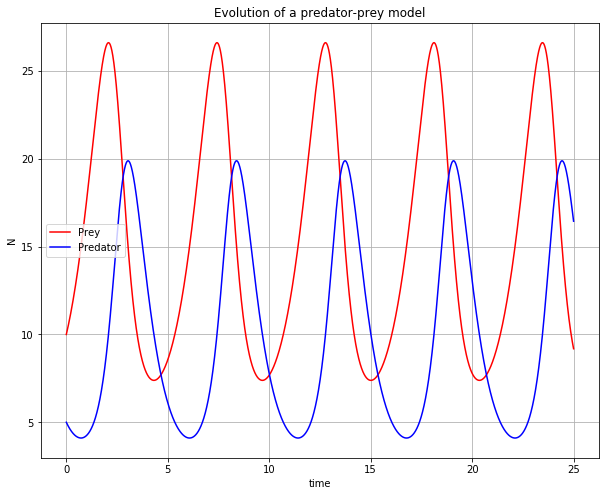

In [2]:
# Plotting the results
prey, predator = X.T
f1 = p.figure(figsize = (10, 8))
p.plot(t, prey, 'r-', label = 'Prey')
p.plot(t, predator, 'b-', label = 'Predator')
p.grid()
p.legend(loc = 'best')
p.xlabel('time')
p.ylabel('N')
p.title('Evolution of a predator-prey model')
p.show()

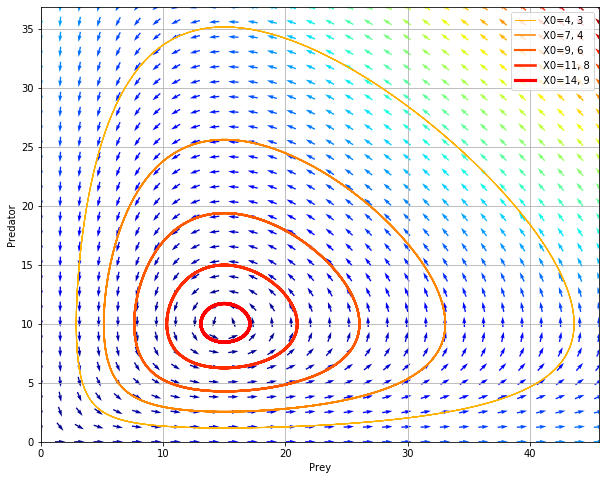

In [6]:
# Plotting direction fields and trajectories
values = np.linspace(0.3, 0.9, 5) # Values of X0 betwen X_f0 and X_f1

vcolors = p.cm.autumn_r(np.linspace(0.3, 1, len(values)))

f2 = p.figure(figsize = (10, 8))
p.xlabel('Prey')
p.ylabel('Predator')


# plotting the trajectories
for v, col in zip(values, vcolors):
    X0 = v * X_f1 # get the starting point
    X = integrate.odeint(dX_dt, X0, t) # we don't need to integrator info here
    p.plot(X[:, 0], X[:, 1], lw = 3.5*v, color = col, label = 'X0=%.f, %.f'%(X0[0], X0[1]))
    
# define grid and compute direction vectors at each grid point
ymax = p.ylim(ymin = 0)[1] # Axis limits from the plot
xmax = p.xlim(xmin = 0)[1]

nb_points = 30

x = np.linspace(0, xmax, nb_points)
y = np.linspace(0, ymax, nb_points)

X1, Y1 = np.meshgrid(x, y) # np.meshgrid() makes a N-dimensional matrix from 1D x and y axes; same thing as for(x): for(y): array[x][y], just much much easier!
DX1, DY1 = dX_dt([X1, Y1]) # compute growth rate at meshgrid points using original ODE

M = (np.hypot(DX1, DY1)) # hypot does element-wise sqrt(x1**2 + x2**2) -> vector normalization!
M[M == 0] = 1.0 # No division by zero!
DX1 /= M # Normalize arrows -> color will code their magnitude later!
DY1 /= M



p.quiver(X1, Y1, DX1, DY1, M, pivot = 'mid', cmap = p.cm.jet)
p.legend()
p.grid()
p.show()

## Brownian Motion
(see https://scipy-cookbook.readthedocs.io/items/BrownianMotion.html)

- Brownian motion is stochastic process of the form

$$X(0) = X_0$$

$$X(t + dt) = X(t) + N(0, \delta^2 dt; t, t + dt)$$

- $N(a, b; t_1, t_2)$ is normally distributed random variable with $\mu = a$ and $\sigma = b$
- $t_1$ and $t_2$ declare the explicity of the statistical independence of $N$ on different time intervals
    - i.e. $[t_1, t_2)$ and $[t_3, t_4)$ are disjointed intervals; this means, that $N(a, b; t_1, t_2)$ are independent
    
- the most complex thing is the reasoning, the calculation is rather simple


In [7]:
from scipy.stats import norm

# Parameters
delta = 0.25
dt = 0.1

# Initial condition
x = 0.0

# Iterations
n = 20


# computing steps of Brownian motion
for k in range(n):
    x = x+ norm.rvs(scale = delta**2 * dt)
    print(x)

-0.005989930124120906
0.0020150682742100428
-0.006258020755264763
-0.0016331187605450473
-0.005474878674853868
-0.0076766035721120614
-0.018583164932187597
-0.015790695459079296
-0.014500975020012487
-0.01334584347811935
-0.01469292181404358
-0.021088931472784563
-0.019291086292723768
-0.015883256904403655
-0.007323503077835995
-0.016789921905220932
-0.015391197229369538
-0.01576574740306791
-0.02629327089013385
-0.013768031370808759


In [8]:
# Implementing function to do that

from math import sqrt
from scipy.stats import norm
import numpy as np
from numba import njit
from pylab import plot, show, grid

#@jit
def brownian(x0, n, dt, delta, out = None):
    """
        Generate Brownian motion (i.e. Wiener process): X(t) = X(0) + N(0, delta**2 * t; 0, t)
    """
    
    x0 = np.asarray(x0)
    
    r = norm.rvs(size = x0.shape + (n, ), scale = delta*sqrt(dt))
    
    if out is None:
        out = np.empty(r.shape)
        
    np.cumsum(r, axis = -1, out = out)
    
    out += np.expand_dims(x0, axis = -1)
    
    return(out)




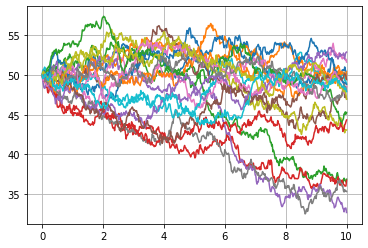

In [9]:
delta = 2

T = 10.0
N = 500
dt = T/N

m = 20 # number of realizations

x = np.empty((m, N+1))

x[:, 0] = 50

brownian(x[:, 0], N, dt, delta, out = x[:, 1:])

t = np.linspace(0.0, N*dt, N+1)

for k in range(m):
    plot(t, x[k])
grid(True)
show()

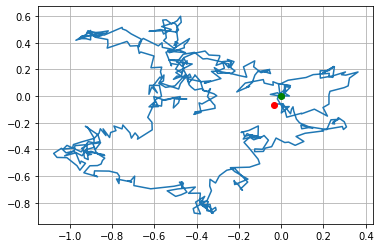

In [10]:
# 2D Brownian Motion

# The Wiener process parameter.
delta = 0.25
# Total time.
T = 10.0
# Number of steps.
N = 500
# Time step size
dt = T/N
# Initial values of x.
x = np.empty((2,N+1))
x[:, 0] = 0.0

brownian(x[:,0], N, dt, delta, out=x[:,1:])

# Plot the 2D trajectory.
plot(x[0],x[1])

# Mark the start and end points.
plot(x[0,0],x[1,0], 'go')
plot(x[0,-1], x[1,-1], 'ro')

# More plot decorations.
grid(True)
show()

## Robust Non-Linear Regression using Scipy

(see https://scipy-cookbook.readthedocs.io/items/robust_regression.html)

- curve fitting by non-linear least squares
    - given pairs $\{(t_i, y_i)i = 1, ..., n \}$, estimate the set of parameters $\mathbf{x}$ defining a non-linear function $\phi(t;\mathbf{x})$ by assuming the model
    
    $$y_i = \phi(t_i; \mathbf{x}) + \epsilon_i$$
    
- with $\epsilon_i$ as measurement error
- with least-squares estimation, we serach for $\mathbf{x}$ as solution of 

$$\frac{1}{2} \sum_{i = 1}^{n} \big( \phi (t_i; \mathbf{x}) - y_i \big)^2 \rightarrow \min_{x}$$


- least-squares is maximum likelihood estimate
    - given that all $\epsilon_i$ are independent and normally distributed random variables
- outliers can contaminate a measurement and interfere with the fitting procedure
    - can lead to solution, which is significantly biased towards the high residuals of the outlier
    
    
- explanation with simple example: consider this optimization problem
 
 
$$\frac{1}{2} \sum_{i = 1}^{n} (a - x)^2 \rightarrow \min_{x}$$

- with the solution in the mean value $a^* = \frac{1}{n} \sum_{i = 1}^{n} x_i$
    - example data are $a = 1$, $n = 4$, $x_1 = 0.9$, $x_2 = 1.05$, $x_3 = 0.95$, $x_4 = 10$ (outlier)
    - $a^* = 3.225$, which isn't true because of the strong influence of the outlier
- well-known and robust estimator is l1-estimator
    - absolute values of residuals are minimized: $$\sum_{i = 1}^{n} | a - x_i | \rightarrow \min_{a}$$
    - the solution is the median of $\{ x_i \}$; in that case the outliers won't affect the solution as strongly
    - $a^* = 1$
    - disadvantage of l1-estimator is, that estimations become hard, when the function is non-differentiable (general problem of nin-linear optimization)
    - i.e. we're better off when we stay with differentiable problems, but try to incorporate robustness in the estimation
- we try to introduce a sublinear function $\rho (z)$ (sublinear = slower growth than linear) and reformulate the least-square(-like) optimization problem: $$\frac{1}{2} \sum_{i = 1}^{n} \rho \big( \phi (t_i; \mathbf{x}) - y_i \big) \rightarrow \min_{x}$$
    - this can be reduced to standard non-linear least-squares by modifying a vector of residuals and Jacobian on each iteration
    - $\rightarrow$ gradient and Hessian approximation match the ones of the objective function
    
- implementation for $\rho$
    1. Linear function, which gives a standard least squares: $\rho(z) = z$
    2. Huber loss: